In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [356]:
data = pd.read_excel('../Data/Data_finance_lab3.xlsx', sheet_name='data_final')

In [ ]:
data.head()

In [ ]:
data.info()

In [347]:
missing_values = data.isnull().sum()
missing_values

APP_ID                         0
DISBURSALDATE                  0
REPORT_DATE                    0
TERM_TMP                       0
PRODUCT_NAME                   0
LOANAMOUNT_NOT_INSURANCE       0
INSURANCE_FEE                  0
LA                             0
EFF_RATE                       0
TERM                           0
COUNT_TERM_RECEIPT            91
flag term                     91
SUM_RECEIPT_AMT               91
Unnamed: 13                 4849
flag loan amt                 91
flag final                    91
RESULT_YES/NO                  0
EMI                            0
GENDER                         0
AGE                            0
Number of Children          4200
PERSONAL_INCOME                0
ADDITIONAL_INCOME              0
PERSONAL_EXPENSE               0
FAMILY_INCOME                  0
FAMILY_EXPENSE                 0
MARITAL_STATUS                 0
EDUCATION                      0
City                           0
ADDRESS_CURRENT_CITY           0
PROVINCE_C

In [357]:
data['COUNT_TERM_RECEIPT'] = data['COUNT_TERM_RECEIPT'].fillna(data['COUNT_TERM_RECEIPT'].mean())
data['SUM_RECEIPT_AMT'] = data['SUM_RECEIPT_AMT'].fillna(data['SUM_RECEIPT_AMT'].mean())
data['Number of Children'] = data['Number of Children'].fillna(0)

data['RESULT_YES/NO'] = data['RESULT_YES/NO'].astype('object')
data['INCOME'] = data['PERSONAL_INCOME'] + data['ADDITIONAL_INCOME'] + data['FAMILY_INCOME'] - data['FAMILY_EXPENSE'] - data['PERSONAL_EXPENSE']

data.isnull().sum()


APP_ID                         0
DISBURSALDATE                  0
REPORT_DATE                    0
TERM_TMP                       0
PRODUCT_NAME                   0
LOANAMOUNT_NOT_INSURANCE       0
INSURANCE_FEE                  0
LA                             0
EFF_RATE                       0
TERM                           0
COUNT_TERM_RECEIPT             0
flag term                     91
SUM_RECEIPT_AMT                0
Unnamed: 13                 4849
flag loan amt                 91
flag final                    91
RESULT_YES/NO                  0
EMI                            0
GENDER                         0
AGE                            0
Number of Children             0
PERSONAL_INCOME                0
ADDITIONAL_INCOME              0
PERSONAL_EXPENSE               0
FAMILY_INCOME                  0
FAMILY_EXPENSE                 0
MARITAL_STATUS                 0
EDUCATION                      0
City                           0
ADDRESS_CURRENT_CITY           0
PROVINCE_C

In [ ]:
datetime_vars = data.select_dtypes(include='datetime').columns
datetime_vars

Index(['DISBURSALDATE', 'REPORT_DATE'], dtype='object')

In [ ]:
result_counts = data.groupby(['DISBURSALDATE', 'RESULT_YES/NO']).size().reset_index(name='counts')
result_counts

pivot_table = result_counts.pivot(index='DISBURSALDATE', columns='RESULT_YES/NO', values='counts').fillna(0)

pivot_table.columns = ['Label_0', 'Label_1']

print(pivot_table)


In [349]:
categorical_vars = data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_vars

['PRODUCT_NAME',
 'RESULT_YES/NO',
 'GENDER',
 'MARITAL_STATUS',
 'EDUCATION',
 'City',
 'ADDRESS_CURRENT_CITY',
 'PROVINCE_CURRENT']

In [39]:
for var in categorical_vars:
    plt.figure(figsize=(10,5))
    sns.countplot(x=var, data=data)
    plt.xticks(rotation=45)
    plt.show()


In [358]:
numerical_vars = data.select_dtypes(include=[np.number]).columns.to_list()
numerical_vars

['APP_ID',
 'TERM_TMP',
 'LOANAMOUNT_NOT_INSURANCE',
 'INSURANCE_FEE',
 'LA',
 'EFF_RATE',
 'TERM',
 'COUNT_TERM_RECEIPT',
 'flag term',
 'SUM_RECEIPT_AMT',
 'Unnamed: 13',
 'flag loan amt',
 'flag final',
 'EMI',
 'AGE',
 'Number of Children',
 'PERSONAL_INCOME',
 'ADDITIONAL_INCOME',
 'PERSONAL_EXPENSE',
 'FAMILY_INCOME',
 'FAMILY_EXPENSE',
 'INCOME']

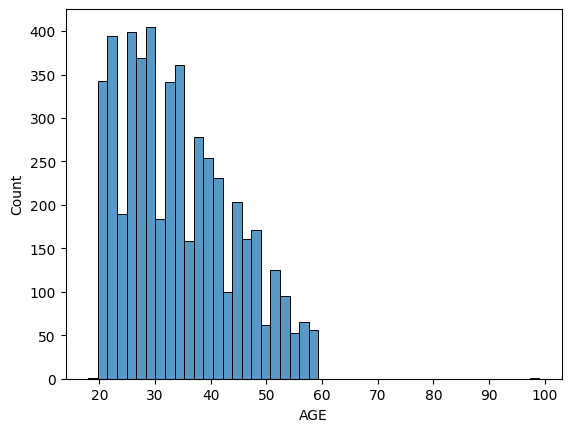

In [43]:
for var in numerical_vars:
    sns.histplot(x=data[var])
    plt.show()


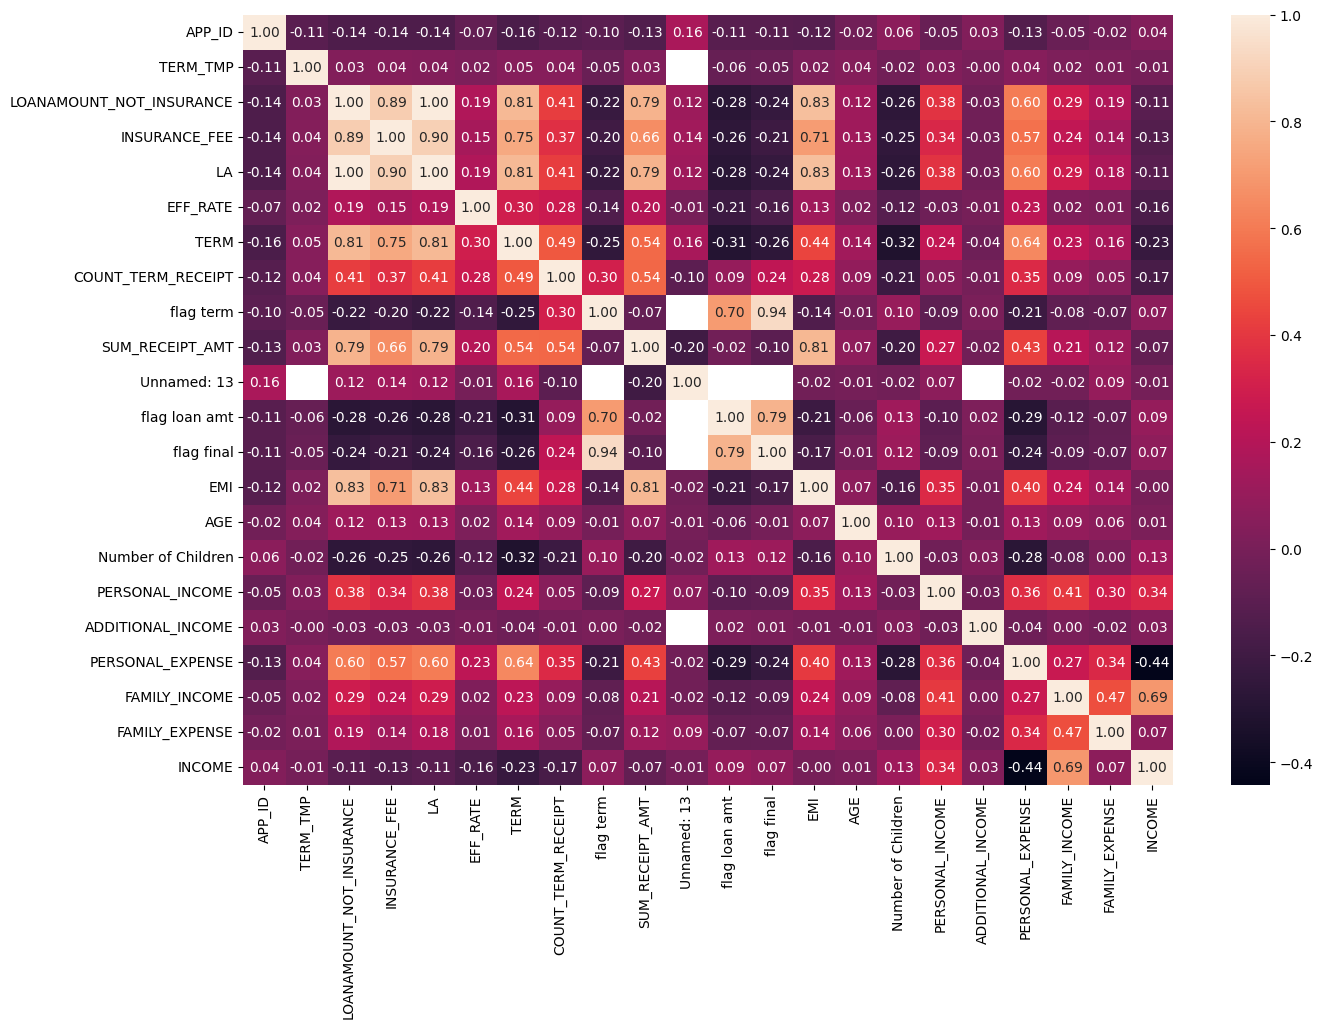

In [ ]:
corr_matrix = data[numerical_vars].corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.show()

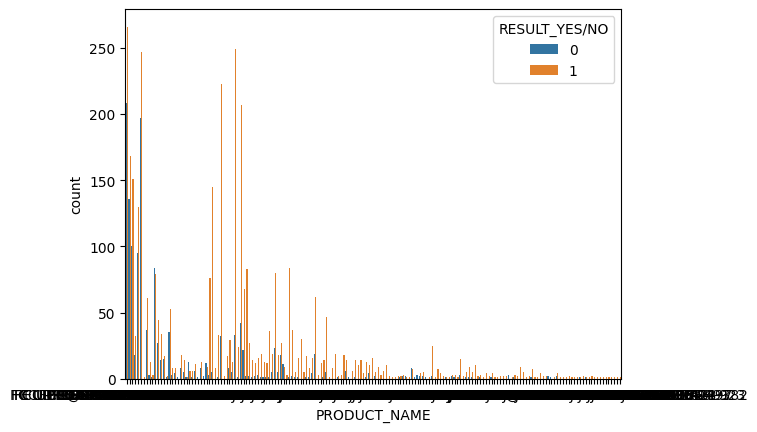

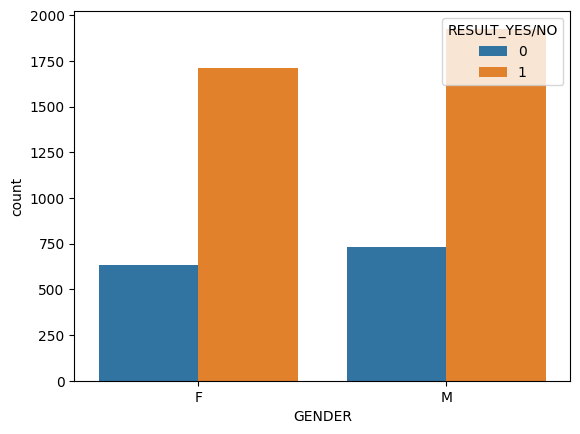

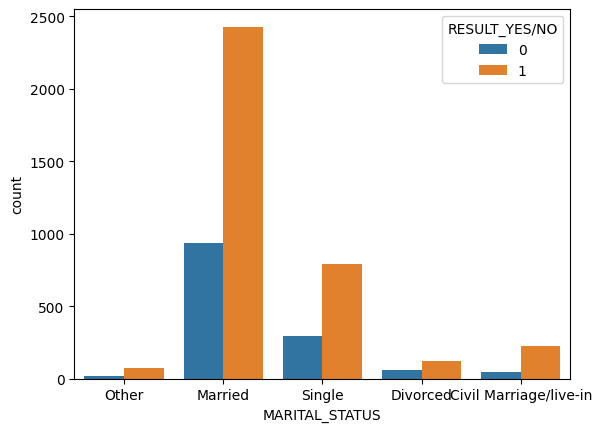

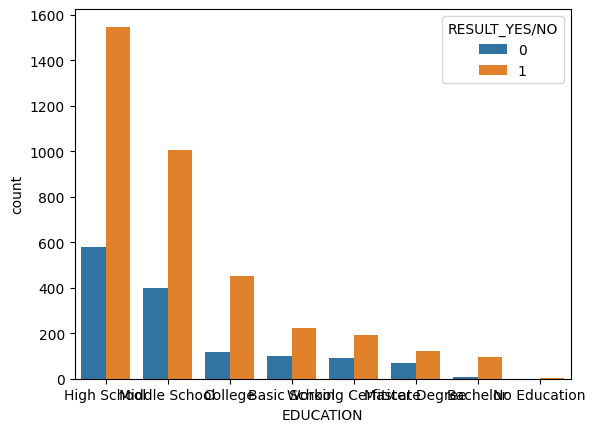

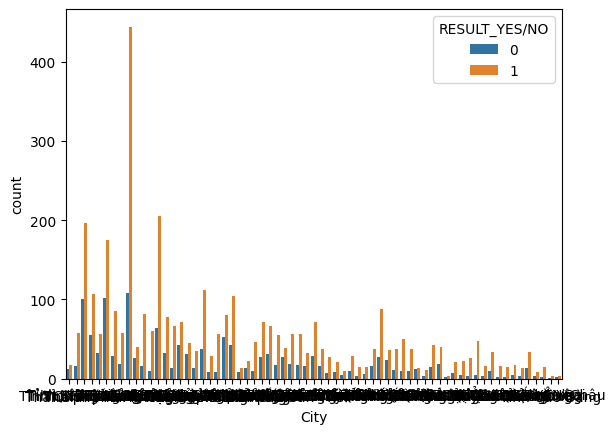

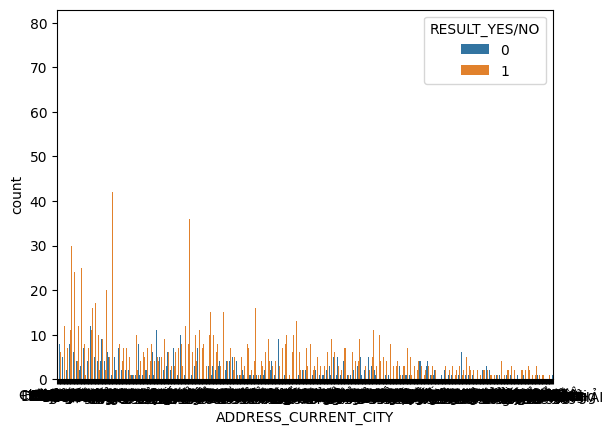

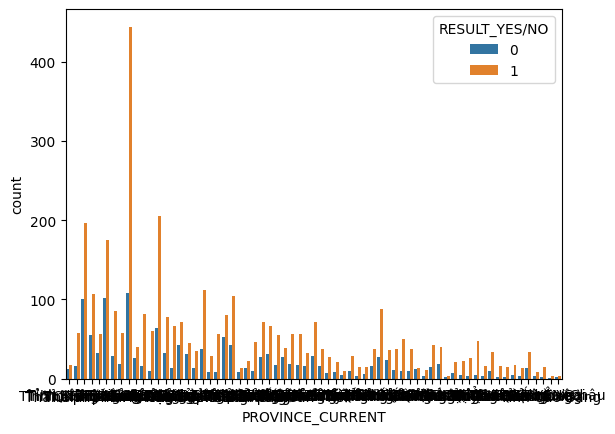

In [359]:
for var in categorical_vars:
    if var != 'RESULT_YES/NO':
        sns.countplot(x=var, hue='RESULT_YES/NO', data=data)
        plt.show()


In [ ]:
for var in numerical_vars:
    sns.boxplot(x='RESULT_YES/NO', y=var, data=data)
    plt.show()


In [640]:
data_train = data.copy()

In [641]:
epsilon = 1e-6
data_train['ID'] = data_train['EMI'] / (data_train['INCOME'] + epsilon)

In [642]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler


numerical_vars = data_train.select_dtypes(include=[np.number]).columns.to_list()
categorical_vars = data_train.select_dtypes(include=['object', 'category']).columns.to_list()

label_encoders = {}
for var in categorical_vars:
    if data_train[var].dtype == 'object' or data_train[var].dtype.name == 'category':
        le = LabelEncoder()
        data_train[var] = le.fit_transform(data_train[var].astype(str))
        label_encoders[var] = le


scaler = StandardScaler()
scaled_features = scaler.fit_transform(data_train[numerical_vars])

for i, var in enumerate(numerical_vars):
    data_train[var] = scaled_features[:, i]



In [643]:
attributes = []

data_no_outliers = data_train.copy()

for attribute in attributes:
    Q1 = data_train[attribute].quantile(0.25)
    Q3 = data_train[attribute].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data_no_outliers = data_no_outliers[(data_no_outliers[attribute] >= lower_bound) & (data_no_outliers[attribute] <= upper_bound)]


In [662]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score

_data_train = data_no_outliers

columns = _data_train.columns.to_list()
columns_train = [
    'EFF_RATE', 
    'PRODUCT_NAME', 
    'LOANAMOUNT_NOT_INSURANCE', 
    'INSURANCE_FEE', 
    'GENDER', 
    'SUM_RECEIPT_AMT', 
    'INCOME', 
    'COUNT_TERM_RECEIPT', 
    'City', 
    'ADDRESS_CURRENT_CITY', 
    'EDUCATION', 
    'AGE',
]


drop_columns = list(set(columns).symmetric_difference(set(columns_train)))

X = _data_train.drop(columns=drop_columns) 
y_train = _data_train['RESULT_YES/NO']
X_train = X[y_train == 1]

X_test = data_train.drop(columns=drop_columns) 
y = data_train['RESULT_YES/NO']



In [663]:
oc_svm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.03)  

oc_svm.fit(X_train)
decision_scores = oc_svm.decision_function(X_test)

Optimal threashold: -0.0004879093769220577


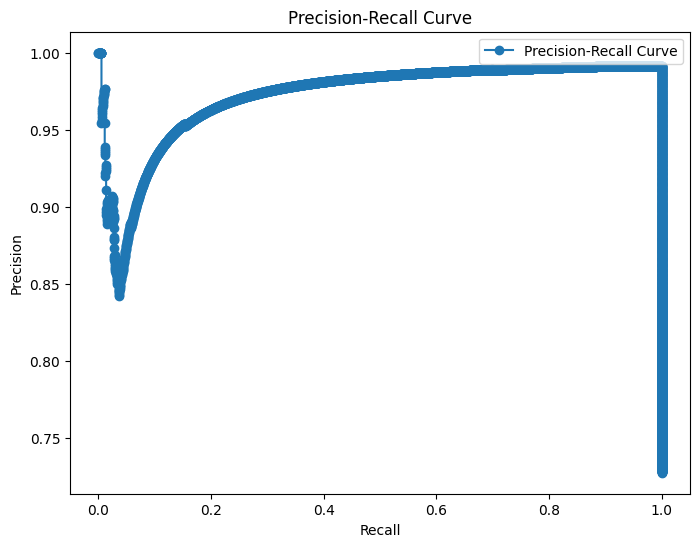

In [664]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y, decision_scores)

f1_scores = 2 * (precision * recall) / (precision + recall)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threashold: {optimal_threshold}")

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='o', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


In [665]:
y_pred_new = (decision_scores >= optimal_threshold).astype(int)

print(classification_report(y, y_pred_new))
average_precision = average_precision_score(y, y_pred_new)
print(f"Average Precision: {average_precision}")

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1364
           1       0.99      1.00      1.00      3636

    accuracy                           0.99      5000
   macro avg       1.00      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000

Average Precision: 0.9912758996728462
